# 03 · Feature engineering — describing "market state" in numbers a model can use

> ⏱️ **~30 min** &nbsp;·&nbsp; 🧭 **SOP:** Phase 3b · Feature factory &nbsp;·&nbsp; 🧩 **Feeds:** ALL editions — MasterVP/Monster live on the **Volume-Profile** features; KenKem on **EMA/Ichimoku**
>
> 🎯 **Goal:** Turn raw OHLC bars into 41 causal, normalized features that capture trend, momentum, volatility, structure & time.
>
> 🔑 **The one thing to remember:** A good feature is **causal** (uses only the past) and **normalized** (comparable across price levels) — usually a *distance* or *slope*, never a raw price.

## Notebook 03 in one breath

> **Where we are.** We have clean M1/M3 bars. A learning algorithm can't do much with a raw close
> price of `68,214.5` — it needs *descriptors of the situation*: is price stretched above its average?
> is momentum fading? is volatility high? is price near a heavily-traded level? This notebook is the
> Python mirror of `pipeline/features.py` + `pipeline/indicators.py`, and it is where research lives or
> dies. **Feature engineering is the highest-leverage skill in applied data science.**

**What you'll learn:**
1. Why **raw price is a bad feature**, and the two properties every good feature needs
   (**causality** + **normalization**).
2. The five feature *families* and the intuition for each: **trend / momentum / volatility / direction
   / structure**, plus time-of-day.
3. How each indicator is computed (**EMA, RSI, ATR, ADX/DI, Volume Profile, Ichimoku**) with runnable
   code from the real pipeline.
4. How to **prove a feature is lookahead-free** — the test that protects the whole project.

In [1]:
# --- Standard setup (run me first) -------------------------------------------------
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import duckdb                 # streams Parquet/CSV without loading it all into RAM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _find_root(start: Path) -> Path:
    """Walk up until we see the repo's pipeline/ + data/ — works from any sub-dir."""
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "pipeline").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError("repo root (with pipeline/ and data/) not found above " + str(start))

ROOT = _find_root(Path.cwd())
DATA = ROOT / "data"
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))   # so `from pipeline import ...` works (the real Layer-1 code)
con  = duckdb.connect()       # one in-memory DuckDB connection we reuse all notebook

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

print("repo root :", ROOT)
print("data dir  :", DATA)

repo root : /Users/tokyotechies/Workspace/KEM/dquants
data dir  : /Users/tokyotechies/Workspace/KEM/dquants/data


In [2]:
# Load one year of real M3 bars and the project's actual indicator/feature code.
from pipeline import indicators as ind, features as feat
bars = pd.read_parquet(DATA / "processed" / "bars_btcusd_M3_2026.parquet").sort_values("ts").reset_index(drop=True)
c, h, l = bars["close"], bars["high"], bars["low"]
print(f"loaded {len(bars):,} M3 bars  ({bars.ts.min()} -> {bars.ts.max()})")
bars.head(3)

loaded 76,800 M3 bars  (2026-01-01 00:00:00 -> 2026-06-09 23:57:00)


,ts,open,high,low,close,spread_mean,spread_max,tick_count
0,2026-01-01 00:00:00,"87,516.8","87,561.9","87,498.6","87,545.4",12.6,12.6,105
1,2026-01-01 00:03:00,"87,543.9","87,685.8","87,543.9","87,615.8",12.6,12.6,95
2,2026-01-01 00:06:00,"87,617.8","87,639.2","87,559.7","87,614.8",12.6,12.6,92


## Step 1 · Why raw price is a terrible feature

Two reasons, both fatal:

1. **It's non-stationary** (notebook 06 proves this formally). BTC at $20k in 2022 and $100k in 2025
   are different worlds; a rule learned at one level won't transfer to the other.
2. **It's not comparable across instruments.** A "$50 move" is huge for gold ($2,000) and tiny for BTC
   ($68,000). A model can't learn one rule for both.

The fix is **normalization**: express everything as a *relative* quantity — a **distance** as a
fraction of price, or a **slope** as a percent change. Watch the difference between a raw EMA and the
feature we actually store.

In [3]:
ema50 = ind.ema(c, 50)                       # raw indicator value (non-stationary, ~price scale)
ema50_dist = (c - ema50) / c                 # the FEATURE: % distance of price above/below the EMA
cmp = pd.DataFrame({"close": c, "ema_50 (raw)": ema50, "ema_50_dist (feature)": ema50_dist}).dropna()
print(cmp.describe().loc[["mean", "std", "min", "max"]].round(4).to_string())
print("\nRaw EMA drifts with price (std in the hundreds); the *distance* feature is a tidy, "
      "mean-zero, instrument-neutral number.")
cmp.tail(3)

        close  ema_50 (raw)  ema_50_dist (feature)
mean 75,653.3      75,661.5                -0.0001
std  8,778.39      8,772.69                 0.0039
min  59,121.1      60,016.1                -0.0517
max  97,849.7      97,470.4                 0.0337

Raw EMA drifts with price (std in the hundreds); the *distance* feature is a tidy, mean-zero, instrument-neutral number.


,close,ema_50 (raw),ema_50_dist (feature)
76797,"61,681.3","61,730.6",-0.000799103
76798,"61,664.6","61,728",-0.00102895
76799,"61,687.3","61,726.4",-0.000633904


> 📘 **Concept — feature normalization.** Almost every feature in this project is a **distance**
> (`(price − level)/price`) or a **slope** (`pct_change`). That single design choice is why the same
> features — and ultimately the same C++ strategy core — work on both BTC and XAU. When you invent a
> feature, ask: *"is this number comparable at any price level, on any instrument?"* If not, normalize it.

## Step 2 · The causality contract (the rule that outranks all others)

> 🧠 **Every feature at bar `t` may use only bars `≤ t`.** No exceptions. A single leaked future value
> turns a worthless strategy into a "genius" one — in the backtest only. All our indicators are written
> to be **causal**: EMA is a recursive function of the past; RSI/ATR/ADX use Wilder smoothing of past
> values; rolling windows look *backward*; the Volume Profile uses the *prior* completed day.

We'll *prove* our features obey this at the end of the notebook. First, the families.

## Step 3 · Family 1 — Trend (EMA: where is price vs its moving averages?)

> 📘 **Concept — moving average & EMA.** A moving average smooths price to reveal trend. A **Simple MA**
> equally weights the last *n* bars; an **Exponential MA (EMA)** weights recent bars more, so it reacts
> faster. We use EMA with the **MT5 convention** (`adjust=False` — a pure recursion) so the eventual
> MQL5 EA reproduces identical values. The project tracks an EMA *ribbon* (12/25/50/75/100/200) and, for
> each, the **distance** and **slope**; the spread of the ribbon (`ema_compression`) flags squeeze vs
> expansion.

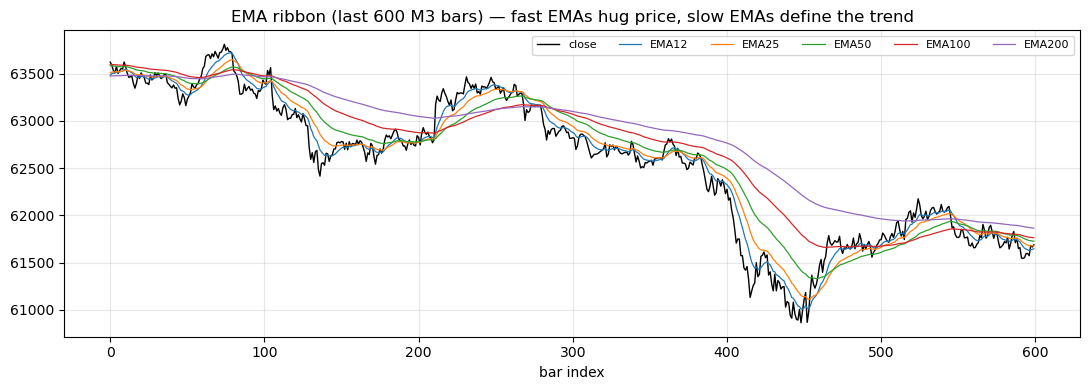

In [4]:
ribbon = {n: ind.ema(c, n) for n in [12, 25, 50, 100, 200]}
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(c.values[-600:], color="black", lw=1, label="close")
for n, e in ribbon.items():
    ax.plot(e.values[-600:], lw=0.9, label=f"EMA{n}")
ax.set_title("EMA ribbon (last 600 M3 bars) — fast EMAs hug price, slow EMAs define the trend")
ax.legend(ncol=6, fontsize=8); ax.set_xlabel("bar index"); plt.tight_layout(); plt.show()

## Step 4 · Family 2 — Momentum (RSI: is the move overextended?)

> 📘 **Concept — RSI.** The Relative Strength Index maps the ratio of recent gains to recent losses
> onto a 0–100 scale (Wilder smoothing). High (>70) = lots of recent up-moves ("overbought"); low (<30)
> = "oversold". For us it's less a buy/sell trigger and more a *state descriptor*: we store its value
> **and** its slope **and** its acceleration, so the model sees momentum *turning*, not just its level.

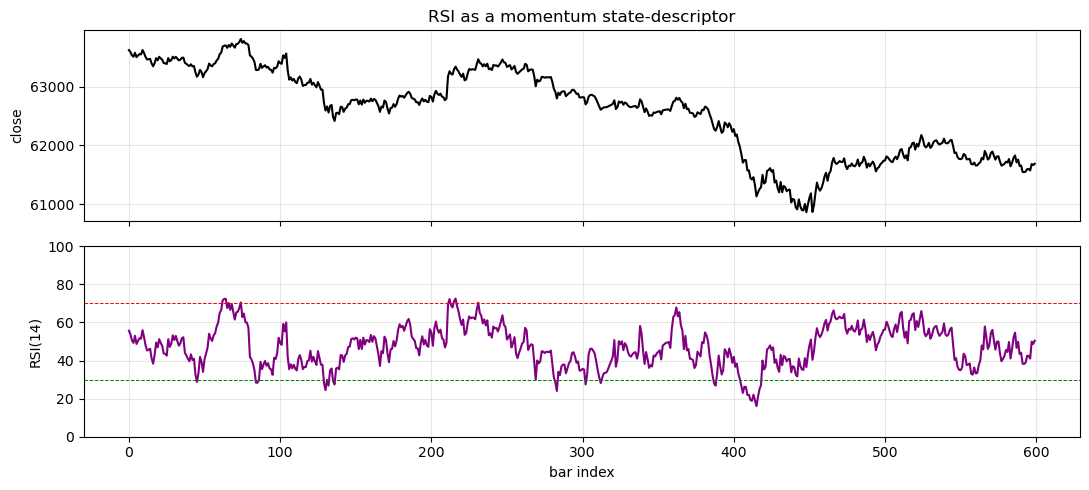

In [5]:
rsi14 = ind.rsi(c, 14)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a1.plot(c.values[-600:], color="black"); a1.set_ylabel("close")
a2.plot(rsi14.values[-600:], color="purple"); a2.axhline(70, ls="--", c="r", lw=0.7); a2.axhline(30, ls="--", c="g", lw=0.7)
a2.set_ylabel("RSI(14)"); a2.set_ylim(0, 100); a2.set_xlabel("bar index")
a1.set_title("RSI as a momentum state-descriptor"); plt.tight_layout(); plt.show()

## Step 5 · Family 3 — Volatility (ATR: how much does it move, and is that unusual?)

> 📘 **Concept — ATR (Average True Range).** ATR is the average size of a bar's range (including gaps),
> Wilder-smoothed. It's the project's **unit of risk**: stops and targets are placed at *multiples of
> ATR*, not fixed dollars, so the strategy auto-adapts to calm vs wild regimes. We also store
> `atr_pct` — ATR's **rolling percentile** over ~a day — which answers "is volatility high *for this
> market, right now*?" (a normalized, comparable signal).

In [6]:
atr14 = ind.atr(h, l, c, 14)
atr_pct = ind.rolling_percentile(atr14, 480)            # 480 M3 bars ≈ 1 day
print("ATR is a *price-scale* number; atr_pct is a normalized 0..1 'how unusual' signal.")
pd.DataFrame({"atr": atr14, "atr_pct": atr_pct}).dropna().describe().loc[["mean","std","min","max"]].round(4)

ATR is a *price-scale* number; atr_pct is a normalized 0..1 'how unusual' signal.


,atr,atr_pct
mean,109.214,0.4922
std,61.9401,0.31
min,14.6974,0.0021
max,667.669,1


## Step 6 · Family 4 — Direction (ADX / DI: is there a trend, and which way?)

> 📘 **Concept — ADX & DI.** The Directional Movement system splits "is there a trend?" (**ADX**, 0–100,
> direction-agnostic) from "which way?" (**+DI vs −DI**). `adx > 25` ≈ trending; `di_spread = +DI − −DI`
> gives the sign. Phase-5 discovery found DI matters *more* than RSI here, so the VP strategies use an
> **ADX/DI regime gate** to only trade breakouts when a trend is actually present.

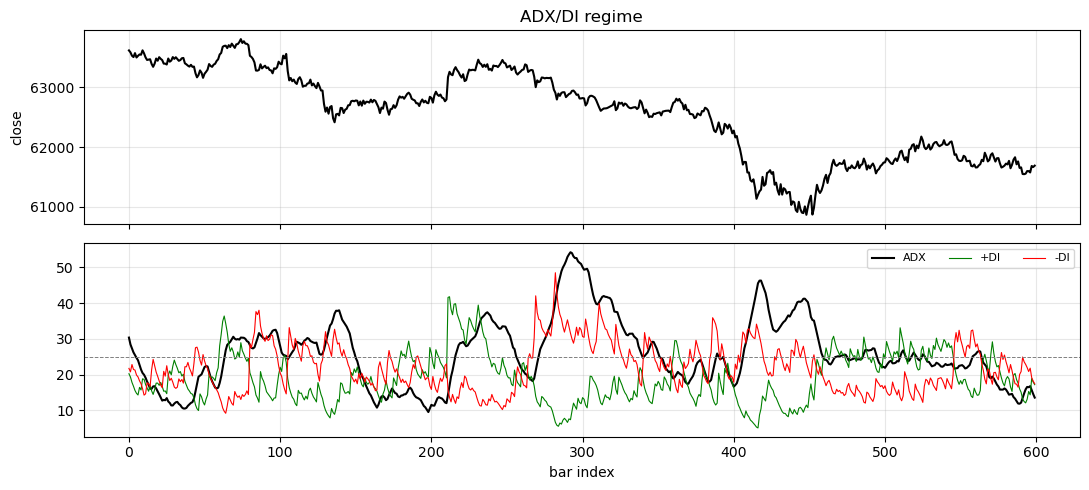

In [7]:
adx, plus_di, minus_di = ind.dmi_adx(h, l, c, 14)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a1.plot(c.values[-600:], color="black"); a1.set_ylabel("close"); a1.set_title("ADX/DI regime")
a2.plot(adx.values[-600:], color="black", label="ADX")
a2.plot(plus_di.values[-600:], color="green", lw=0.8, label="+DI")
a2.plot(minus_di.values[-600:], color="red", lw=0.8, label="-DI")
a2.axhline(25, ls="--", c="gray", lw=0.7); a2.legend(ncol=3, fontsize=8); a2.set_xlabel("bar index")
plt.tight_layout(); plt.show()

## Step 7 · Family 5 — Structure (Volume Profile: where did trading actually happen?)

This is **the** feature family for MasterVP and Monster, and the project's #1 discovery finding.

> 📘 **Concept — Volume Profile / Market Profile.** Instead of asking "what was the price over *time*",
> VP asks "how much *activity* happened at each *price*". Build a histogram of activity (here weighted by
> `tick_count`) across price bins for a session, and you get:
> - **POC** (Point of Control) — the most-traded price (the peak of the histogram).
> - **VAH / VAL** (Value Area High/Low) — the band containing ~70% of activity.
>
> These are the levels real traders defend and target. We store price's **distance** to each
> (`dist_poc`, `dist_vah`, `dist_val`) — and, to stay causal, we use **yesterday's** profile to judge
> **today's** price. Let's compute one day's profile by hand.

day 2026-03-22:  POC=68,792  VAH=69,469  VAL=68,434


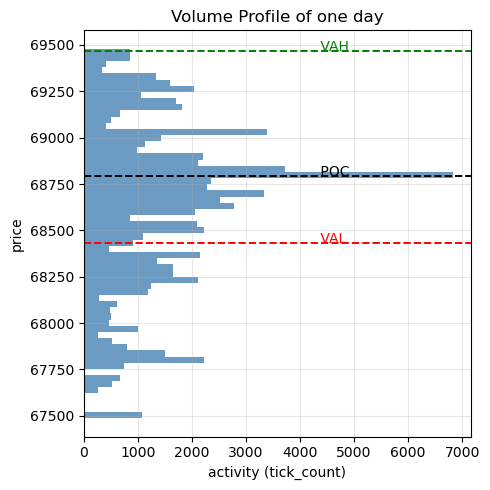

In [8]:
one = bars[bars.ts.dt.date == bars.ts.dt.date.iloc[len(bars)//2]]      # a middle day
typ = (one.high + one.low + one.close) / 3.0
poc, vah, val = ind.volume_profile_levels(typ.to_numpy(), one["tick_count"].to_numpy(), bins=100)
print(f"day {one.ts.dt.date.iloc[0]}:  POC={poc:,.0f}  VAH={vah:,.0f}  VAL={val:,.0f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(typ, bins=60, weights=one["tick_count"], orientation="horizontal", color="steelblue", alpha=0.8)
for lvl, name, color in [(poc,"POC","black"), (vah,"VAH","green"), (val,"VAL","red")]:
    ax.axhline(lvl, color=color, lw=1.4, ls="--"); ax.text(ax.get_xlim()[1]*0.6, lvl, f" {name}", color=color)
ax.set_xlabel("activity (tick_count)"); ax.set_ylabel("price"); ax.set_title("Volume Profile of one day")
plt.tight_layout(); plt.show()

## Step 8 · Family 6 — Time (hour / session / day-of-week)

> 📘 **Concept — cyclical / categorical time features.** Markets behave differently by session (Asia /
> London / New York). Discovery found **hour-of-day is consistently one of the most important features**
> and is sign-stable across years. We encode `hour`, `dow`, and a named `session` bucket. (A subtlety
> for later: hour is *cyclical* — 23 and 0 are adjacent — which tree models handle fine but linear
> models need sin/cos encoding for.)

## Step 9 · Assemble all 41 features with the real pipeline

Everything above is wired together in `pipeline.features.build_features`. One call produces the exact
feature frame the discovery and strategy work consumes.

In [9]:
F = feat.build_features(bars, "M3")
feature_cols = [col for col in F.columns if col not in ("ts", "close")]
print(f"feature frame: {F.shape[0]:,} rows × {len(feature_cols)} features")
print("families present:", ", ".join(sorted({col.split('_')[0] for col in feature_cols})))
F[["ts", "close", "ema_50_dist", "rsi_14", "adx", "di_spread", "atr_pct", "dist_poc", "dist_kijun", "hour"]].tail(4)

feature frame: 76,800 rows × 41 features
families present: adx, atr, cloud, di, dist, dow, ema, hour, rsi, session


,ts,close,ema_50_dist,rsi_14,adx,di_spread,atr_pct,dist_poc,dist_kijun,hour
76796,2026-06-09 23:48:00,"61,573.4",-0.00258539,41.0402,16.7728,-7.46746,0.4,-0.0236246,-0.00245138,23
76797,2026-06-09 23:51:00,"61,681.3",-0.000799103,49.8983,15.6256,-0.27125,0.4875,-0.0218341,-0.000498611,23
76798,2026-06-09 23:54:00,"61,664.6",-0.00102895,48.6756,14.5604,-0.257047,0.460417,-0.0221117,-0.000306335,23
76799,2026-06-09 23:57:00,"61,687.3",-0.000633904,50.4515,13.5712,-0.246588,0.402083,-0.0217347,0.000143546,23


Notice the **warmup**: the slowest indicator (EMA200, and the ~1-day ATR-percentile window) needs
history before it's valid, so the first few hundred bars carry `NaN`s **by design**. We report them and
let downstream code drop them — we never back-fill (that would leak the future, per notebook 01).

In [10]:
warm = F[feature_cols].isna().any(axis=1)
first_valid = int((~warm).to_numpy().argmax())
print(f"warmup rows with any NaN (leading): ~{first_valid:,} bars, then the frame is dense")
F[feature_cols].isna().sum().sort_values(ascending=False).head(6)

warmup rows with any NaN (leading): ~480 bars, then the frame is dense


dist_poc           480
dist_vah           480
dist_val           480
atr_pct            479
cloud_thickness     77
dist_kijun          25
dtype: int64

## Step 10 · Prove it's causal (the test that guards the whole project)

The claim: *truncating the future cannot change a past feature.* We compute features on the full bars,
then again on the bars **cut short** at bar `k`, and compare a feature value at an index well before the
cut. If they match, no information flowed backward. This is the idea behind
`pipeline/tests/test_features_labels.py::test_feature_frame_is_causal`.

In [11]:
k = 5000                                   # cut the data here (throw away the "future")
probe = 4000                               # inspect a bar safely before the cut
full  = feat.build_features(bars, "M3")
short = feat.build_features(bars.iloc[:k].copy(), "M3")

checks = {}
for colname in ["ema_50_dist", "rsi_14", "adx", "atr_pct", "dist_poc", "dist_kijun"]:
    a, b = full[colname].iloc[probe], short[colname].iloc[probe]
    checks[colname] = abs((a - b)) if pd.notna(a) and pd.notna(b) else float("nan")
res = pd.Series(checks, name="abs_diff_at_probe")
print("Max |difference| across features at the probe bar:", f"{res.max():.2e}")
print("=> 0 (to float precision) means NO future leaked into the past. Causality holds.\n")
res

Max |difference| across features at the probe bar: 0.00e+00
=> 0 (to float precision) means NO future leaked into the past. Causality holds.



ema_50_dist   0
rsi_14        0
adx           0
atr_pct       0
dist_poc      0
dist_kijun    0
Name: abs_diff_at_probe, dtype: float64

## 🎯 Your turn

1. **Engineer a new feature.** Add `ema_50_dist` *minus* `ema_200_dist` (short-vs-long stretch). Plot
   it. Does it spike before reversals? You just proposed a hypothesis for notebook 07.
2. **Break causality on purpose.** Make a "feature" `c.shift(-1) / c - 1` (next bar's return) and run it
   through the Step-10 causality check. Watch the difference blow up — that's exactly what the test
   catches.
3. **VP on gold.** Build a day of XAU bars (notebook 02, exercise 2) and compute its Volume Profile.
   Are gold's POC/VAH/VAL as crisp as BTC's?
4. **Redundancy preview.** Compute `F[["ema_50_dist","ema_75_dist","ema_100_dist"]].corr()`. Adjacent
   EMAs are ~0.99 correlated — a redundancy we'll formally prune in notebook 08.

➡️ **Next:** notebook **04** — features describe *now*; **labels** describe the *future* we want to predict.